In [1]:
!pip -q install wandb

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import wandb

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive
from wandb.integration.keras import WandbMetricsLogger

# Keeping the seed fixed so the experiments are more reproducible
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("WandB version:", wandb.__version__)

TensorFlow version: 2.19.0
WandB version: 0.25.1


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Log in to Weights & Biases
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 3.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

...

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 3.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


False

In [5]:
# Loading the tabular dataset from the student wellness dataset
tabular_base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/tabular"

train_tabular_path = os.path.join(tabular_base_path, "train.csv")
test_tabular_path = os.path.join(tabular_base_path, "test.csv")

train_tabular_df = pd.read_csv(train_tabular_path)
test_tabular_df = pd.read_csv(test_tabular_path)

print("Train shape:", train_tabular_df.shape)
print("Test shape:", test_tabular_df.shape)
train_tabular_df.head()

Train shape: (240, 13)
Test shape: (80, 13)


,sample_id,sleep_hours,study_hours,attendance_pct,stress_score,caffeine_cups,exercise_minutes,screen_time_hours,assignment_delay_days,social_minutes,mood_score,label,label_id
0,train_0000,8.18,1.46,96.50,29.41,0.00,31.98,4.65,0.18,59.80,7.15,low_risk,0
1,train_0001,7.33,4.78,85.40,56.27,2.13,21.41,6.44,0.54,55.54,6.25,moderate_risk,1
2,train_0002,5.49,4.82,84.34,68.45,2.50,14.48,8.14,3.57,34.95,4.93,high_risk,2
3,train_0003,5.88,6.09,64.93,79.86,4.23,19.29,8.86,4.16,5.11,3.65,critical_risk,3
4,train_0004,8.45,3.04,88.01,22.32,1.08,47.19,5.55,0.72,68.15,8.07,low_risk,0


In [6]:
# Turning label names into numeric classes
label_to_index = {
    label: idx for idx, label in enumerate(sorted(train_tabular_df["label"].unique()))
}

index_to_label = {idx: label for label, idx in label_to_index.items()}

train_tabular_df["label_id"] = train_tabular_df["label"].map(label_to_index)
test_tabular_df["label_id"] = test_tabular_df["label"].map(label_to_index)

print(label_to_index)

{'critical_risk': 0, 'high_risk': 1, 'low_risk': 2, 'moderate_risk': 3}


In [7]:
# Keeping only numeric feature columns
excluded_columns = ["label", "label_id"]

numeric_feature_columns = [
    col for col in train_tabular_df.columns
    if col not in excluded_columns and pd.api.types.is_numeric_dtype(train_tabular_df[col])
]

X_train_full = train_tabular_df[numeric_feature_columns].values
y_train_full = train_tabular_df["label_id"].values

X_test = test_tabular_df[numeric_feature_columns].values
y_test = test_tabular_df["label_id"].values

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (192, 10)
Validation shape: (48, 10)
Test shape: (80, 10)


In [8]:
# This helper builds a simple tabular classification model
def build_wandb_model(input_dim, dropout_rate=0.2, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu"),
        layers.Dense(len(label_to_index), activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [9]:
# This helper runs one experiment and logs it to Weights & Biases
def run_wandb_experiment(run_name, dropout_rate, learning_rate, epochs=15, batch_size=16):
    wandb.init(
        project="cmpe258-assignment4-student-wellness",
        name=run_name,
        config={
            "dropout_rate": dropout_rate,
            "learning_rate": learning_rate,
            "epochs": epochs,
            "batch_size": batch_size,
            "dataset": "student_wellness_tabular"
        },
        reinit=True
    )

    model = build_wandb_model(
        input_dim=X_train.shape[1],
        dropout_rate=dropout_rate,
        learning_rate=learning_rate
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[WandbMetricsLogger()]
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    wandb.log({
        "final_test_loss": test_loss,
        "final_test_accuracy": test_acc
    })

    print(f"{run_name} -> Test Accuracy: {test_acc:.4f}")

    wandb.finish()
    return history, test_acc

In [10]:
# Baseline run
history_baseline, acc_baseline = run_wandb_experiment(
    run_name="baseline_run",
    dropout_rate=0.2,
    learning_rate=1e-3
)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


baseline_run -> Test Accuracy: 0.8750


epoch/accuracy,▁▃▄▄▄▅▅▆▆▇▇▇█▇█
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▄▄▃▃▃▂▂▂▁▁▁
epoch/val_accuracy,▁▄▄▄▄▆▇▇▇██████
epoch/val_loss,█▆▅▅▄▄▃▃▃▂▂▂▁▁▁
final_test_accuracy,▁
final_test_loss,▁
epoch/accuracy,0.97396
epoch/epoch,14
epoch/learning_rate,0.001


In [11]:
# Run with higher dropout
history_dropout, acc_dropout = run_wandb_experiment(
    run_name="higher_dropout_run",
    dropout_rate=0.4,
    learning_rate=1e-3
)

higher_dropout_run -> Test Accuracy: 0.8375


epoch/accuracy,▁▃▄▅▅▅▅▆▇▇▇▇███
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▃▃▃▂▂▂▂▂▁▁▁
epoch/val_accuracy,▁▃▃▃▄▅▆▆▇▇▇▇███
epoch/val_loss,█▆▅▄▄▃▃▃▂▂▂▂▁▁▁
final_test_accuracy,▁
final_test_loss,▁
epoch/accuracy,0.85938
epoch/epoch,14
epoch/learning_rate,0.001


In [12]:
# Run with lower learning rate
history_low_lr, acc_low_lr = run_wandb_experiment(
    run_name="lower_learning_rate_run",
    dropout_rate=0.2,
    learning_rate=5e-4
)

lower_learning_rate_run -> Test Accuracy: 0.7750


epoch/accuracy,▁▂▄▅▅▅▅▅▆▆▆▇▇██
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▇▆▅▄▄▃▃▃▂▂▂▂▁▁
epoch/val_accuracy,▁▂▅▅▅▅▅▅▆▆▇████
epoch/val_loss,█▇▆▅▄▄▃▃▃▂▂▂▁▁▁
final_test_accuracy,▁
final_test_loss,▁
epoch/accuracy,0.80208
epoch/epoch,14
epoch/learning_rate,0.0005


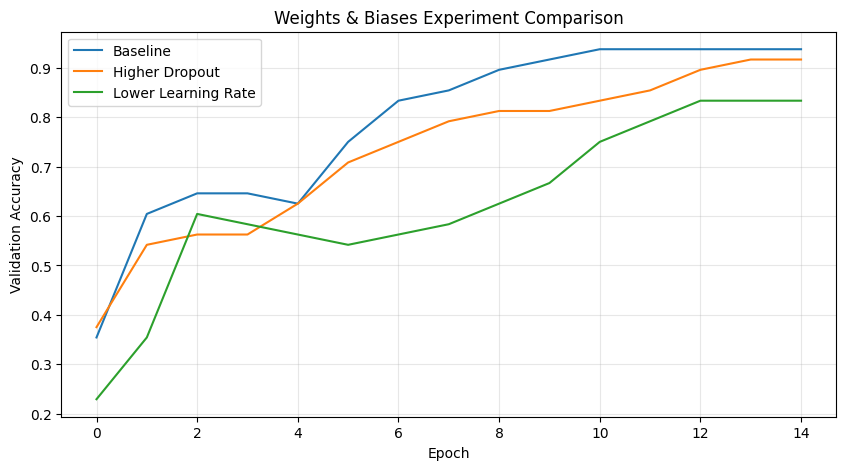

In [13]:
# Comparing the validation accuracy curves from the three WandB runs
plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history["val_accuracy"], label="Baseline")
plt.plot(history_dropout.history["val_accuracy"], label="Higher Dropout")
plt.plot(history_low_lr.history["val_accuracy"], label="Lower Learning Rate")
plt.title("Weights & Biases Experiment Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
# Looking at a few predictions from the best-performing run
best_model_type = "baseline"
best_acc = acc_baseline

if acc_dropout > best_acc:
    best_model_type = "dropout"
    best_acc = acc_dropout

if acc_low_lr > best_acc:
    best_model_type = "low_lr"
    best_acc = acc_low_lr

print("Best run type:", best_model_type)
print("Best test accuracy:", round(best_acc, 4))

Best run type: baseline
Best test accuracy: 0.875


In [15]:
# Training the best configuration one more time locally so I can show sample predictions
if best_model_type == "baseline":
    final_model = build_wandb_model(X_train.shape[1], dropout_rate=0.2, learning_rate=1e-3)
elif best_model_type == "dropout":
    final_model = build_wandb_model(X_train.shape[1], dropout_rate=0.4, learning_rate=1e-3)
else:
    final_model = build_wandb_model(X_train.shape[1], dropout_rate=0.2, learning_rate=5e-4)

final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=16,
    verbose=0
)

sample_predictions = final_model.predict(X_test[:8], verbose=0)
predicted_classes = np.argmax(sample_predictions, axis=1)

for i in range(8):
    print("True Label     :", index_to_label[y_test[i]])
    print("Predicted Label:", index_to_label[predicted_classes[i]])
    print("-" * 50)

True Label     : low_risk
Predicted Label: moderate_risk
--------------------------------------------------
True Label     : critical_risk
Predicted Label: critical_risk
--------------------------------------------------
True Label     : high_risk
Predicted Label: high_risk
--------------------------------------------------
True Label     : moderate_risk
Predicted Label: moderate_risk
--------------------------------------------------
True Label     : low_risk
Predicted Label: low_risk
--------------------------------------------------
True Label     : critical_risk
Predicted Label: critical_risk
--------------------------------------------------
True Label     : high_risk
Predicted Label: high_risk
--------------------------------------------------
True Label     : moderate_risk
Predicted Label: moderate_risk
--------------------------------------------------


In [16]:
# Final summary so the main WandB experiment results are easy to explain
print("Colab 11 Results Summary")
print("-" * 45)
print(f"Baseline Run Accuracy       : {acc_baseline:.4f}")
print(f"Higher Dropout Run Accuracy : {acc_dropout:.4f}")
print(f"Lower LR Run Accuracy       : {acc_low_lr:.4f}")

Colab 11 Results Summary
---------------------------------------------
Baseline Run Accuracy       : 0.8750
Higher Dropout Run Accuracy : 0.8375
Lower LR Run Accuracy       : 0.7750


### Final Observation

In this notebook, I used Weights & Biases to track multiple tabular classification experiments on the student wellness dataset. I logged different runs with different hyperparameter choices, including dropout and learning rate changes, and then compared their validation and test performance. This notebook helped me understand how experiment tracking tools make it much easier to organize runs, compare models, and keep a clean record of training behavior.